# Deep learning on text and images

## Load modules from repo

In [1]:
# Le code suivant dans un notebook permet de :
# - autoriser les imports de fichiers python de ce repo
# - spécifier les chemins relativement à la racine du repo plutôt que relativement au notebook

import os

# Ce code cherche le dossier racine en remontant dans l'arborescence
# jusqu'à ce qu'il trouve le dossier 'src'.
# Cela le rend indépendant de l'endroit où vous lancez le notebook.
try:
    # On part du dossier du notebook
    notebook_dir = os.path.dirname(__file__)
except NameError:
    # __file__ n'existe pas en mode interactif, on utilise le répertoire de travail
    notebook_dir = os.getcwd()

# On remonte jusqu'à trouver un dossier contenant 'src'
project_root = notebook_dir
while not os.path.isdir(os.path.join(project_root, 'src')):
    parent_dir = os.path.dirname(project_root)
    if parent_dir == project_root: # On a atteint la racine du système
        raise FileNotFoundError("Impossible de trouver le dossier 'src'. Vérifiez la structure du projet.")
    project_root = parent_dir

os.chdir(project_root)

In [2]:
os.getcwd()

'/home/val/Documents/Dev/DataScientest/Rakuten'

In [3]:
import src
from src.preprocessing.core import load_reproducible_split
from src.preprocessing.pipelines.deep_learning_on_text_and_images import preprocess_features
from src.preprocessing.pipelines.deep_learning import load_preprocessors, save_preprocessors
from src.models.on_text_and_images.deep_learning import define_model, get_custom_hyperparams, log_experiment, grad_cam, show_grad_cam_cnn
from src.models.on_images.deep_learning import get_efficientnet_selection


from pathlib import Path
import pandas as pd
# import numpy as np

2025-11-21 11:12:12.521642: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-21 11:12:12.567918: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-21 11:12:14.265377: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1763719935.396915   11187 gpu_device.cc:2020] Created device /job:localhost/rep

In [4]:
import importlib
importlib.reload(src.preprocessing.core)
importlib.reload(src.preprocessing.pipelines.deep_learning_on_text_and_images)
importlib.reload(src.preprocessing.pipelines.deep_learning)
importlib.reload(src.models.on_text_and_images.deep_learning)
importlib.reload(src.models.on_images.deep_learning)

<module 'src.models.on_images.deep_learning' from '/home/val/Documents/Dev/DataScientest/Rakuten/src/models/on_images/deep_learning.py'>

## Load tensorflow

In [5]:
import tensorflow as tf

In [6]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [7]:
print(f"tensorflow: {tf.__version__}")

tensorflow: 2.20.0


## Load split dataset

In [8]:
X_train, X_test, y_train, y_test = load_reproducible_split(folder = 'Dataset2')
full_X_train=X_train
full_y_train=y_train

In [9]:
# Distribution of class proportions
y_train.value_counts(normalize=True).describe()

count    27.000000
mean      0.037037
std       0.024767
min       0.008994
25%       0.018268
50%       0.031458
75%       0.056137
max       0.120223
Name: proportion, dtype: float64

## Configuration 1

In [10]:
modality = 'text_and_image'
version=1
artifacts_folder=Path(f'artifacts/on_text_and_images/deep_learning/v{version}')

multimodal_artifacts_folder = Path(f'artifacts/on_text_and_images/deep_learning/v1')
log_file_path = multimodal_artifacts_folder / 'experiments.parquet'
preprocessors_folder = multimodal_artifacts_folder
tensor_board_folder = multimodal_artifacts_folder / "tensorboard_logs"

# fit_preprocessors=True
fit_preprocessors=False

small_train_sample = False  # TODO: set to False for real training or fitting preprocessors
frac=0.1

rebalance_with_weights = True  # True is useful if some classes are ignored by the model. In that case, small_train_sample should be False.

# augment=True  # Augment data for training
augment=False

BATCH_SIZE = 32

RANDOM_SEED = 42

load_model=True
# load_model=False

## Preprocessing

In [11]:
if fit_preprocessors and small_train_sample:
    raise ValueError("When fit_preprocessors=True, small_train_sample should be False so that encoders are fitted on the full training dataset.")

In [12]:
if small_train_sample:
    print(f"{small_train_sample=}")
    X_train=X_train.sample(frac=frac, random_state=RANDOM_SEED)
    y_train=y_train.loc[X_train.index]

In [13]:
y_train.value_counts(normalize=True).describe()

count    27.000000
mean      0.037037
std       0.024767
min       0.008994
25%       0.018268
50%       0.031458
75%       0.056137
max       0.120223
Name: proportion, dtype: float64

In [14]:
y_train.value_counts().describe()

count      27.000000
mean     2516.000000
std      1682.489662
min       611.000000
25%      1241.000000
50%      2137.000000
75%      3813.500000
max      8167.000000
Name: count, dtype: float64

In [15]:
print(X_train.shape)

(67932, 31)


In [16]:
if fit_preprocessors:
    preprocessors = {}
    print('will fit')
else: # load preprocessors
    print('loading')
    preprocessors = load_preprocessors(names=['target','tabular','hash','text_vectorizer'],artifacts_folder=preprocessors_folder)

loading
artifacts/on_text_and_images/deep_learning/v1/preprocessors/target.joblib
artifacts/on_text_and_images/deep_learning/v1/preprocessors/tabular.joblib
artifacts/on_text_and_images/deep_learning/v1/preprocessors/hash.joblib
artifacts/on_text_and_images/deep_learning/v1/preprocessors/text_vectorizer.joblib


In [17]:
train_ds, new_preprocessors, class_weights, train_inputs_dict, y_train_ohe = preprocess_features(X_train, y_train, preprocessors, full_X_train=full_X_train, full_y_train=full_y_train, shuffle=True, BATCH_SIZE = BATCH_SIZE, rebalance_with_weights=rebalance_with_weights, augment=augment)
preprocessors |= new_preprocessors
n_cols_tabular = train_inputs_dict['tabular_input'].shape[1]
n_cols_tabular

24

In [18]:
new_preprocessors

{}

In [19]:
# Save on disk
if fit_preprocessors:
    print('Saving.')
    save_preprocessors(new_preprocessors,artifacts_folder)

In [20]:
test_ds, new_preprocessors, class_weights_test, test_inputs_dict, y_test_ohe = preprocess_features(X_test, y_test, preprocessors, shuffle=False, BATCH_SIZE = BATCH_SIZE, rebalance_with_weights=False, augment=False)

## Model

In [21]:
from tensorflow import keras

### Load or create model

In [22]:
import pandas as pd

try:
    # Load tracker
    tracking_df = pd.read_parquet(log_file_path)
    if tracking_df.empty:
        last_experiment = {}
    else:
        last_experiment = tracking_df.iloc[-1].to_dict()
except FileNotFoundError:
    last_experiment = {}

champion_path=None
if load_model:
    # Récupérer le total d'epochs déjà entraînées
    total_epochs_trained = last_experiment.get('total_epochs', 0)

    arch_version = last_experiment.get('arch_version', 1)

    # Charger le meilleur modèle connu jusqu'à présent (le "champion")
    champion_path = last_experiment.get('best_model_path', None)
    if champion_path and Path(champion_path).exists():
        print(f"Reprise depuis le meilleur modèle de l'expérience : {champion_path}")
        model = keras.models.load_model(champion_path)
        _, base_model = define_model(text_vectorizer=preprocessors['text_vectorizer'], pHash_vocab_size=len(preprocessors['hash'].categories_[0]), md5_vocab_size=len(preprocessors['hash'].categories_[1]), n_cols_tabular=n_cols_tabular, num_classes=27)
    else:
        raise FileNotFoundError("Consider setting load_model=False.")
else:
    arch_version = last_experiment.get('arch_version', 0)
    total_epochs_trained = 0
    last_experiment = {}
    print("Création d'un nouveau modèle.")
    model, base_model = define_model(text_vectorizer=preprocessors['text_vectorizer'], pHash_vocab_size=len(preprocessors['hash'].categories_[0]), md5_vocab_size=len(preprocessors['hash'].categories_[1]), n_cols_tabular=n_cols_tabular, num_classes=27)


Reprise depuis le meilleur modèle de l'expérience : artifacts/on_text_and_images/deep_learning/v1/best_model_arch-11_epoch_index-01_val_accuracy-0.8338_f1-0.8337.keras


In [23]:
if not load_model:
    arch_version = int(input(f"arch_version ? (last: {arch_version})"))

In [24]:
arch_version

11

### Summary

In [25]:
# model.summary()

## Callbacks

### ModelCheckpoint

In [26]:
# # Pick an available filename to save a model.
# arch_version=1
# while True:
#     new_location_for_saving_model = Path(artifacts_folder / f'best_model-{arch_version}.keras')
#     if not new_location_for_saving_model.exists():
#         break
#     arch_version+=1
# # new_location_for_saving_model_weights = Path(artifacts_folder / f'best_model-{arch_version}.h5')
# new_location_for_saving_model


In [27]:
new_location_for_saving_model = artifacts_folder / "candidate_best_model.keras"

In [28]:
# Callback pour sauvegarder le meilleur modèle au fur et à mesure
save = keras.callbacks.ModelCheckpoint(
    new_location_for_saving_model,
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

In [29]:
# # ou sauvegarder l'intégralité du modèle après l'entraînement, c'est-à-dire son architecture et ses poids :
# model.save(new_location_for_saving_model)

### EarlyStopping

In [30]:
from tensorflow.keras.callbacks import EarlyStopping

# Ce callback arrêtera l'entraînement si la métrique ne s'améliore pas
# pendant n epochs consécutives. Il restaurera aussi les poids du meilleur epoch.
early_stopping = EarlyStopping(
    monitor='val_accuracy', # La métrique à surveiller
    patience=5,             # Nombre d'epochs à attendre sans amélioration
    mode='max',             # Choisir le mode selon la métrique à surveiller
    restore_best_weights=True # À la fin, le modèle aura les poids de son meilleur score
)

### ReduceLROnPlateau

In [31]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy', # On surveille la perte sur la validation
    factor=0.2,         # On réduit le LR
    patience=2,         # Si métrique stagne pendant n epochs
    min_lr=1e-6,        # On ne descend pas en dessous de cette valeur
    verbose=1           # Affiche un message quand le LR est réduit
)

### TerminateOnNaN

In [32]:
import tensorflow.keras.callbacks as callbacks
terminate_on_nan = callbacks.TerminateOnNaN()

### TensorBoard

In [33]:
import datetime
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensor_board = callbacks.TensorBoard(
    log_dir = tensor_board_folder / f"{timestamp}-{modality}",
    histogram_freq=1 # Demande à Keras de logger les distributions des poids et biais à chaque epoch
)

## Configuration 2

### max_epochs

In [34]:
import math
# typical_minutes_per_epoch=3.65 * X_train.shape[0] / 6793
typical_minutes_per_epoch=12.46 * X_train.shape[0] / 67932

In [35]:
# max_epochs=2

# # Calculate expected duration
# available_minutes=math.ceil(max_epochs * typical_minutes_per_epoch)
# available_minutes

In [36]:
# Pick max_epochs based on your available time
available_minutes=90

max_epochs=math.floor(available_minutes/typical_minutes_per_epoch)
max_epochs

7

### compilation and callbacks

In [37]:
learning_rate=0.001

In [38]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [39]:
callbacks = [save, early_stopping, reduce_lr, terminate_on_nan, tensor_board]

## Training

In [40]:
raise Exception(f"Are you sure you want to launch training with {available_minutes=}, {max_epochs=}, {champion_path=} ?")

Exception: Are you sure you want to launch training with available_minutes=90, max_epochs=7, champion_path='artifacts/on_text_and_images/deep_learning/v1/best_model_arch-11_epoch_index-01_val_accuracy-0.8338_f1-0.8337.keras' ?

In [ ]:
import time
start = time.time()
model_history = model.fit(train_ds, validation_data=test_ds, epochs=total_epochs_trained + max_epochs, initial_epoch=total_epochs_trained, callbacks=callbacks)
end = time.time()
total_minutes = (end - start)/60
f"{total_minutes=}"

Epoch 1/7


E0000 00:00:1763640108.444723    9618 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-11-20 13:01:49.867912: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91300


2123/2123 ━━━━━━━━━━━━━━━━━━━━ 748s 347ms/step - accuracy: 0.6978 - loss: 1.3380 - val_accuracy: 0.8181 - val_loss: 0.8040 - learning_rate: 0.0010
Epoch 2/7


2025-11-20 13:14:10.576039: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 134233088 bytes after encountering the first element of size 134233088 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


2123/2123 ━━━━━━━━━━━━━━━━━━━━ 731s 344ms/step - accuracy: 0.8533 - loss: 0.6588 - val_accuracy: 0.8338 - val_loss: 0.6948 - learning_rate: 0.0010
Epoch 3/7
2123/2123 ━━━━━━━━━━━━━━━━━━━━ 737s 347ms/step - accuracy: 0.9112 - loss: 0.4317 - val_accuracy: 0.8315 - val_loss: 0.7179 - learning_rate: 0.0010
Epoch 4/7
2123/2123 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.9362 - loss: 0.3322
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
2123/2123 ━━━━━━━━━━━━━━━━━━━━ 739s 348ms/step - accuracy: 0.9462 - loss: 0.2967 - val_accuracy: 0.8125 - val_loss: 0.8606 - learning_rate: 0.0010
Epoch 5/7
2123/2123 ━━━━━━━━━━━━━━━━━━━━ 739s 348ms/step - accuracy: 0.9760 - loss: 0.1779 - val_accuracy: 0.8293 - val_loss: 0.7992 - learning_rate: 2.0000e-04
Epoch 6/7
2123/2123 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.9782 - loss: 0.1612
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
2123/2123 ━━━━━━━━━━━━━━━━━━━━ 738s 348ms/step - accurac

'total_minutes=86.14515005747477'

## Epoch curves

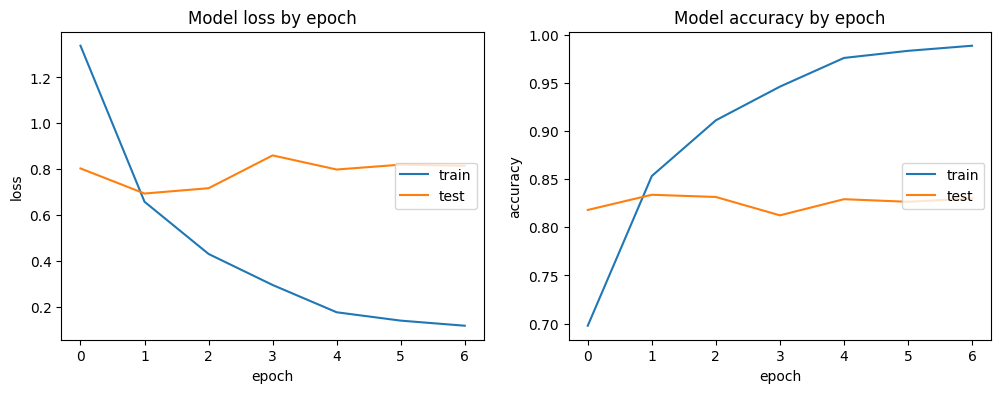

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.subplot(121)
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('Model loss by epoch')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='right')

plt.subplot(122)
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('Model accuracy by epoch')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='right');

## Grad-CAM

In [ ]:
raise Exception("This section takes a while to run.")

In [42]:
from tensorflow.keras import layers

conv_layers = [layer.name for layer in model.layers if isinstance(layer, layers.Conv2D)]
print(len(conv_layers))

75


In [43]:
conv_layers

['stem_conv',
 'block1a_project_conv',
 'block2a_expand_conv',
 'block2a_project_conv',
 'block2b_expand_conv',
 'block2b_project_conv',
 'block3a_expand_conv',
 'block3a_project_conv',
 'block3b_expand_conv',
 'block3b_project_conv',
 'block4a_expand_conv',
 'block4a_se_reduce',
 'block4a_se_expand',
 'block4a_project_conv',
 'block4b_expand_conv',
 'block4b_se_reduce',
 'block4b_se_expand',
 'block4b_project_conv',
 'block4c_expand_conv',
 'block4c_se_reduce',
 'block4c_se_expand',
 'block4c_project_conv',
 'block5a_expand_conv',
 'block5a_se_reduce',
 'block5a_se_expand',
 'block5a_project_conv',
 'block5b_expand_conv',
 'block5b_se_reduce',
 'block5b_se_expand',
 'block5b_project_conv',
 'block5c_expand_conv',
 'block5c_se_reduce',
 'block5c_se_expand',
 'block5c_project_conv',
 'block5d_expand_conv',
 'block5d_se_reduce',
 'block5d_se_expand',
 'block5d_project_conv',
 'block5e_expand_conv',
 'block5e_se_reduce',
 'block5e_se_expand',
 'block5e_project_conv',
 'block6a_expand_conv

In [ ]:
# # 1. Define your step for the middle section (e.g., every 10th layer)
# n = 10

# # 2. Slice the list
# start_layers = conv_layers[:5]
# end_layers = conv_layers[-5:]
# middle_layers = conv_layers[5:-5:n]

# # 3. Combine and remove duplicates (using dict.fromkeys preserves order)
# selected_layers = list(dict.fromkeys(start_layers + middle_layers + end_layers))

# print(f"Selected {len(selected_layers)} layers out of {len(conv_layers)}")
# print(selected_layers)

In [52]:
# selected_layers = get_efficientnet_selection(conv_layers)
selected_layers=['block3b_project_conv', 'block5e_project_conv', 'top_conv']

print(f"Selected {len(selected_layers)} layers:")
print(selected_layers)

Selected 3 layers:
['block3b_project_conv', 'block5e_project_conv', 'top_conv']


In [62]:
# Load some random images from the first 300 images of the test dataset
number_of_images = 4

# 1. unbatch(): breaks the (16, 500, 500, 3) batches into individual (500, 500, 3) items
# 2. shuffle(buffer_size): loads 'buffer_size' items into memory and picks randomly from them.
#    Note: Set buffer_size >= number_of_images (ideally larger, e.g., 100 or 1000 for better randomness).
#          (But buffer_size=2000 takes about 6 seconds. And too big would take too much RAM.)
# 3. batch(number_of_images): groups them back into a batch of 4
# 4. take(1): takes that single batch of 4
random_batch = test_ds.unbatch().shuffle(buffer_size=1200).batch(number_of_images).take(1)

for inputs_dict, labels_batch in random_batch:
    labels = labels_batch.numpy().argmax(axis=1)
    break

print(inputs_dict.keys(), labels.shape)

dict_keys(['text_input', 'tabular_input', 'pHash_input', 'md5_input', 'image_input']) (4,)


new


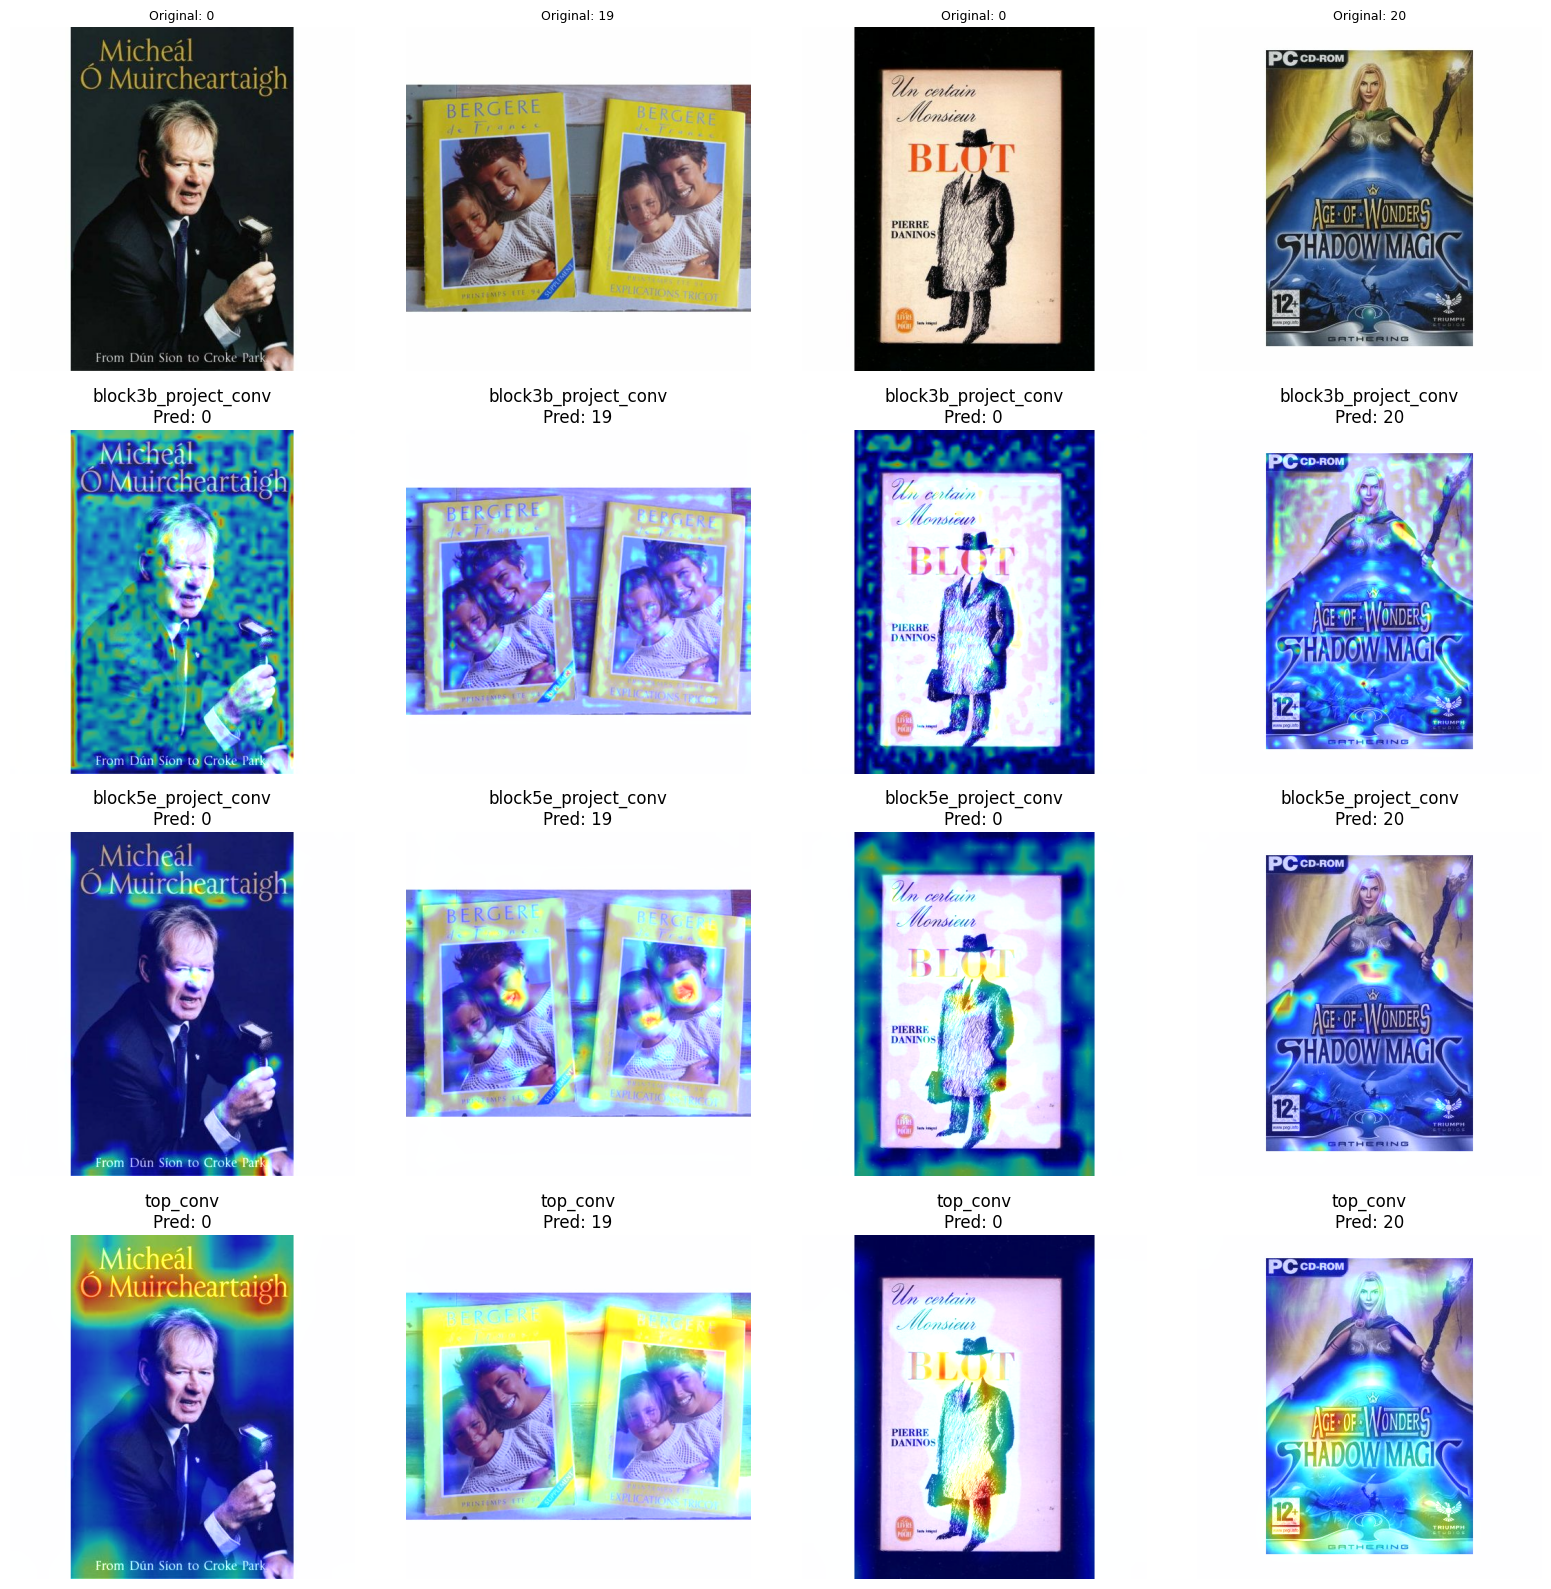

In [63]:
# Takes 10s for 3 layers.
save_plot=True
# save_plot=False
hashes=show_grad_cam_cnn(inputs_dict, model, selected_layers, labels, preprocessors["hash"], save_plot)

In [ ]:
for (k,hash) in enumerate(hashes):
    print(k,end=': ')
    if hash is None:
        print("hash unknown.")
    else:
        display(X_test[X_test['image_hash_md5']==hash])

0: hash unknown.
1: hash unknown.
2: hash unknown.
3: hash unknown.


## Evaluation

In [ ]:
print(f"source venv/bin/activate\ntensorboard --logdir '{tensor_board_folder.resolve()}'")
# To use tensorboard:
# open a terminal and run the two commands below.

source venv/bin/activate
tensorboard --logdir '/home/val/Documents/Dev/DataScientest/Rakuten/artifacts/on_text_and_images/deep_learning/v1/tensorboard_logs'


In [ ]:
tracker = {}
tracker['X_train.shape[0]']=X_train.shape[0]
tracker['actual_epochs']=model_history.epoch[-1] + 1
tracker['minutes_per_epoch'] = total_minutes / tracker['actual_epochs']
tracker

{'X_train.shape[0]': 67932,
 'actual_epochs': 7,
 'minutes_per_epoch': 12.30645000821068}

In [ ]:
tracker['minutes_per_epoch']=max(tracker['minutes_per_epoch'], last_experiment.get('minutes_per_epoch',0))

In [ ]:
#Takes 1m40
y_pred = model.predict(test_ds)

531/531 ━━━━━━━━━━━━━━━━━━━━ 143s 268ms/step


In [ ]:
from sklearn import metrics

In [ ]:
y_test_class = preprocessors['target'].inverse_transform(y_test_ohe.argmax(axis=1))
y_pred_class = preprocessors['target'].inverse_transform(y_pred.argmax(axis=1))

In [ ]:
pd.set_option('display.max_columns',None)
pd.crosstab(y_test_class, y_pred_class, rownames=['True'], colnames=['Predicted'])

Predicted,10,40,50,60,1140,1160,1180,1280,1281,1300,1301,1302,1320,1560,1920,1940,2060,2220,2280,2403,2462,2522,2582,2583,2585,2705,2905
True,,,,,,,,,,,,,,,,,,,,,,,,,,,
10,463,11,0,0,6,2,1,3,5,0,0,0,3,1,2,1,1,0,16,79,0,0,0,0,0,29,0
40,37,364,20,0,16,2,1,12,10,1,0,1,7,1,0,0,9,0,2,3,10,0,0,0,1,5,0
50,1,15,266,3,8,1,1,3,3,4,0,2,12,1,0,1,3,1,0,0,7,1,0,0,3,0,0
60,0,9,12,127,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,15,0,0,0,0,0,0
1140,8,9,4,0,432,1,5,26,2,4,1,1,11,0,1,0,11,1,3,6,0,5,0,0,1,2,0
1160,7,5,2,0,10,745,0,0,4,1,0,0,0,0,0,1,0,0,3,5,6,2,0,0,0,0,0
1180,8,3,2,0,14,4,71,4,14,1,0,7,4,2,0,0,5,0,0,7,2,2,0,1,0,2,0
1280,0,1,3,0,42,2,2,703,26,76,0,28,37,11,3,3,16,5,0,3,0,7,2,1,2,1,0
1281,10,5,1,0,13,5,4,115,208,0,1,15,9,5,0,1,5,1,0,4,3,3,1,1,0,4,0


In [ ]:
candidate_f1_score=metrics.f1_score(y_test_class, y_pred_class, average='weighted')
champion_f1_score = last_experiment.get('weighted_avg_f1_score', 0.0)
candidate_f1_score, champion_f1_score

(0.833691846453115, 0.0)

In [ ]:
tracker['weighted_avg_f1_score'] = candidate_f1_score

In [ ]:
import pandas as pd
report=metrics.classification_report(y_test_class, y_pred_class, output_dict=True)
report=pd.DataFrame(report).transpose()
report

,precision,recall,f1-score,support
10,0.587563,0.743178,0.656272,623.000000
40,0.803532,0.725100,0.762304,502.000000
50,0.786982,0.791667,0.789318,336.000000
60,0.969466,0.765060,0.855219,166.000000
1140,0.752613,0.808989,0.779783,534.000000
1160,0.975131,0.941846,0.958199,791.000000
1180,0.797753,0.464052,0.586777,153.000000
1280,0.686523,0.721766,0.703704,974.000000
1281,0.707483,0.502415,0.587571,414.000000
1300,0.902584,0.899901,0.901241,1009.000000


In [ ]:
# Summary over classes
report.iloc[:-3].describe()

,precision,recall,f1-score,support
count,27.000000,27.000000,27.000000,27.000000
mean,0.833010,0.801626,0.812825,629.037037
std,0.101885,0.122711,0.103809,420.759339
min,0.587563,0.464052,0.586777,153.000000
25%,0.780604,0.746339,0.769945,310.000000
50%,0.821429,0.808989,0.804227,534.000000
75%,0.915185,0.880060,0.879111,953.500000
max,1.000000,0.982759,0.991304,2042.000000


In [ ]:
# positive correlation between support and another measure can suggest class imbalance hurts performance
report.corr()

,precision,recall,f1-score,support
precision,1.000000,0.529283,0.820416,0.016452
recall,0.529283,1.000000,0.917371,0.069831
f1-score,0.820416,0.917371,1.000000,0.053497
support,0.016452,0.069831,0.053497,1.000000


In [ ]:
tracker['weighted_avg_f1_score']=metrics.f1_score(y_test_class, y_pred_class, average='weighted')
tracker['weighted_avg_f1_score']

0.833691846453115

In [ ]:
tracker['min_f1_score']=report['f1-score'].iloc[:-3].describe()['min']
tracker['std_f1_score']=report['f1-score'].iloc[:-3].describe()['std']
tracker

{'X_train.shape[0]': 67932,
 'actual_epochs': 7,
 'minutes_per_epoch': 12.30645000821068,
 'weighted_avg_f1_score': 0.833691846453115,
 'min_f1_score': np.float64(0.5867768595041323),
 'std_f1_score': np.float64(0.10380907080417258)}

## Update tracker

In [ ]:
tracker['comment']="Same as previous run, but with max_epochs=7 instead of max_epochs=4. Done because tensorboard epoch plots looked broken."
tracker['comment']

'Same as previous run, but with max_epochs=7 instead of max_epochs=4. Done because tensorboard epoch plots looked broken.'

In [ ]:
import numpy as np
if candidate_f1_score > champion_f1_score:
    print("Sauvegarde du modèle.")
    keep_candidate=True

    best_epoch_in_session_idx = np.argmax(model_history.history['val_accuracy'])
    best_epoch_global = total_epochs_trained + best_epoch_in_session_idx
    best_val_accuracy = model_history.history['val_accuracy'][best_epoch_in_session_idx]
    tracker['val_accuracy'] = best_val_accuracy

    # Construire le nouveau nom de fichier informatif
    new_champion_filename = f"best_model_arch-{arch_version}_epoch_index-{best_epoch_global:02d}_val_accuracy-{best_val_accuracy:.4f}_f1-{candidate_f1_score:.4f}.keras"
    new_champion_path = artifacts_folder / new_champion_filename

    # Renommer le fichier candidat pour en faire le nouveau champion
    os.rename(new_location_for_saving_model, new_champion_path)

    tracker['best_model_path'] = str(new_champion_path)
    print(new_champion_path)

    # Supprimer l'ancien champion pour garder le dossier propre
    if champion_path and Path(champion_path).exists():
        print(f"\nEffacement de l'ancien modèle chargé {champion_path=} .")
        os.remove(champion_path)
else:
    raise Exception("Le candidat n'a pas battu le modèle chargé.")
    keep_candidate=False


Sauvegarde du modèle.
artifacts/on_text_and_images/deep_learning/v1/best_model_arch-11_epoch_index-01_val_accuracy-0.8338_f1-0.8337.keras


In [ ]:
tracker['epoch_index'] = best_epoch_global
tracker['total_epochs'] = best_epoch_global + 1

In [ ]:
to_track=['version','arch_version','max_epochs','rebalance_with_weights','BATCH_SIZE','learning_rate','timestamp','modality']
tracker |= {k: globals()[k] for k in to_track}
tracker |= get_custom_hyperparams(model, base_model)

In [ ]:
tracker

{'X_train.shape[0]': 67932,
 'actual_epochs': 7,
 'minutes_per_epoch': 12.30645000821068,
 'weighted_avg_f1_score': 0.833691846453115,
 'min_f1_score': np.float64(0.5867768595041323),
 'std_f1_score': np.float64(0.10380907080417258),
 'comment': 'Same as previous run, but with max_epochs=7 instead of 4. Done because epoch plots were not decent.',
 'val_accuracy': 0.8338435888290405,
 'best_model_path': 'artifacts/on_text_and_images/deep_learning/v1/best_model_arch-11_epoch_index-01_val_accuracy-0.8338_f1-0.8337.keras',
 'epoch_index': np.int64(1),
 'total_epochs': np.int64(2),
 'version': 1,
 'arch_version': 11,
 'max_epochs': 7,
 'rebalance_with_weights': True,
 'BATCH_SIZE': 32,
 'learning_rate': 0.001,
 'timestamp': '20251120-130033',
 'modality': 'text_and_image',
 'dense_layers_sizes': {'tabular_dense_1': 64,
  'image_dense': 128,
  'tabular_dense_2': 32,
  'dense': 64,
  'final_dense_1': 256},
 'embedding_dims': {'text_embedding': 128,
  'pHash_embedding': 16,
  'md5_embedding': 

In [ ]:
if not keep_candidate:
    raise Exception("Sure you want to delete current candidate model?")

In [ ]:
if not keep_candidate:
    os.remove(new_location_for_saving_model)

In [ ]:
raise Exception("Sure you want to save the current values of `tracker`? Consider editing the comment.")

Exception: Sure you want to save the current values of `tracker`? Consider editing the comment.

In [ ]:
# Saves tracker as a new row of parquet file (creates the parquet file if necessary)
log_experiment(tracker, loaded_model=load_model, log_file_path=log_file_path)

Log pour l'expérience arch_version 11 ajouté dans artifacts/on_text_and_images/deep_learning/v1/experiments.parquet .


## Show tracking logs

In [ ]:
pd.set_option('max_colwidth', None)

In [ ]:
tracking_df = pd.read_parquet(log_file_path)
tracking_df

,modality,version,arch_version,rebalance_with_weights,X_train.shape[0],BATCH_SIZE,minutes_per_epoch,total_epochs,learning_rate,val_accuracy,weighted_avg_f1_score,min_f1_score,std_f1_score,dense_layers_sizes,embedding_dims,timestamp,comment,best_model_path
0,image,1,2,False,6793,32,1.998601,10,0.001,0.569713,0.528593,0.000000,0.247884,256_128_64_32,16_16,None,Decreased frac from 0.3 to 0.1 for small train sample size to try reducing overfitting even on a small sample. Added data augmentation. Changed Dropout rate from .5 to .7. Added L2 penalties to dense layers.,artifacts/on_images/deep_learning/v1/best_model_sv-2_epochs-10_f1-0.5286.keras
1,image,1,2,False,20380,32,3.867331,8,0.001,0.584609,0.563841,0.000000,0.239801,256_128_64_32,16_16,None,Increased frac from 0.1 to 0.3.,artifacts/on_images/deep_learning/v1/best_model_sv-1_epoch_index-02_val_loss-1.7413_f1-0.5638.keras
2,image,1,3,False,6793,32,2.024143,10,0.001,0.566710,0.527659,0.000000,0.243439,128_64_32_16,8_8,None,"Decreased frac from 0.3 to 0.1. Set dropout rate from 0.7 to 0.5. Reduced dense layers and hash embeddings. Training curve is less steep and validation curve goes higher, which suggests overfitting has been reduced.",artifacts/on_images/deep_learning/v1/best_model_sv-1_epoch_index-04_val_loss-1.8077_f1-0.5277.keras
3,image,1,4,True,6793,32,1.954997,13,0.001,0.541922,0.490818,0.000000,0.270646,128_64_32_16,8_8,None,"Added Dropout(0.5) after concatenation layer. Set rebalance_with_weights=True. Less overfitting: performance is better on validation than on train until epoch 7, and train performance curve is less steep.",artifacts/on_images/deep_learning/v1/best_model_sv-4_epoch_index-07_val_loss-1.8789_f1-0.4908.keras
4,image,1,4,True,20380,32,3.115025,4,0.001,0.562529,0.499731,0.000000,0.276383,128_64_32_16,8_8,None,Increased frac from .1 to .3.,artifacts/on_images/deep_learning/v1/best_model_sv-4_epoch_index-03_val_loss-1.7963_f1-0.4997.keras
5,image,1,5,True,20380,32,3.080263,3,0.001,0.566945,0.506920,0.000000,0.255305,128_64_32_16,8_8,None,Removed dropout layer before softmax. Performance better but more overfitting.,artifacts/on_images/deep_learning/v1/best_model_sv-5_epoch_index-02_val_loss-1.7414_f1-0.5069.keras
6,image,1,6,True,6793,32,1.781595,6,0.001,0.558585,0.537182,0.000000,0.223538,256_128_64_32,16_16,None,Frac back to .1. Reverted layers/embeddings to higher sizes and uncommented Dropout before softmax.,artifacts/on_images/deep_learning/v1/best_model_sv-6_epoch_index-05_val_loss-1.9153_f1-0.5372.keras
7,image,1,7,True,6793,16,2.911669,5,0.001,0.473976,0.410351,0.000000,0.261518,256_128_64_32,16_16,20251004-151611,Unfroze base model. Batch size from 32 to 16 because memory error.,artifacts/on_images/deep_learning/v1/best_model_sv-7_epoch_index-04_val_loss-2.1782_f1-0.4104.keras
8,image,1,8,True,6793,32,1.819877,4,0.001,0.573775,0.523869,0.000000,0.235614,256_128_64_32,16_16,20251006-101001,"Unfroze base model, so batch size back to 32. Lowered first dropout rate from .5 to .2.",artifacts/on_images/deep_learning/v1/best_model_sv-8_epoch_index-03_val_loss-1.9175_f1-0.5239.keras
9,image,1,9,True,67932,32,8.565354,3,0.001,0.591733,0.570463,0.012821,0.211199,256_128_64_32,16_16,20251006-130338,Full training set. Set callbacks to val_accuracy instead of val_loss.,artifacts/on_images/deep_learning/v1/best_model_sv-9_epoch_index-01_val_accuracy-0.5917_f1-0.5705.keras


In [ ]:
old_log_file_path='artifacts/on_images/deep_learning/v1/2025-10-02 experiments-v1.parquet'

In [ ]:
tracking_df0 = pd.read_parquet(old_log_file_path)
tracking_df0

,subversion,started_from_subversion,rebalance_with_weights,X_train.shape[0],BATCH_SIZE,minutes_per_epoch,max_epochs,actual_epochs,learning_rate,val_accuracy,weighted_avg_f1_score,min_f1_score,std_f1_score,dense_layers_sizes,embedding_dims,comment
0,1,<NA>,False,6793,32,2.058333,2,2,0.001,0.538100,0.498881,0.000000,0.238552,256_128_64_32,16_16,"Test dataset was shuffled, which induces bias on the metric. Seed not set on small training sample. No callbacks."
1,2,1,False,6793,32,1.807693,4,4,0.001,0.595737,0.585677,0.179894,0.192174,256_128_64_32,16_16,Test dataset no longer shuffled. Seed set on small training sample. Callbacks set.
2,3,1,False,6793,32,1.674025,29,7,0.001,0.599976,0.593786,0.182796,0.191047,256_128_64_32,16_16,
3,4,3,False,20380,32,2.657786,8,4,0.001,0.608220,0.598100,0.254545,0.180580,256_128_64_32,16_16,Increased frac from 0.1 to 0.3 for small train sample size.


## Convert tracking log for Google Sheets

In [ ]:
tracking_df = pd.read_parquet(log_file_path)

tracking_df['augment']=True
tracking_df.loc[10:,'augment']=False

def image_prep_value(embedding=16, augment=False):
    s=f'numeric features  StandardScaler, "hash features OrdinalEncoder, embedding {int(embedding)}", load image 3 channels'
    if augment:
        s=f'{s}, "augmentation: RandomFlip(""horizontal""), RandomRotation(0.1), RandomZoom(0.1)"'
    return s

def image_prep_of_row(row):
    if row['modality']=='text':
        return ''
    if "16" in row['embedding_dims']:
        return image_prep_value(embedding=16, augment=row['augment'])
    if "8_8" in row['embedding_dims']:
        return image_prep_value(embedding=8, augment=row['augment'])
    raise ValueError(row)

tracking_df["preprocessing image"] = tracking_df.apply(image_prep_of_row,axis=1)

cols=list(tracking_df.loc[:,:'rebalance_with_weights'].columns) + ["preprocessing image",'best_model_path','BATCH_SIZE','weighted_avg_f1_score','val_accuracy','min_f1_score','std_f1_score','comment']
tracking_df=tracking_df[cols]
tracking_df=tracking_df.drop(columns=['arch_version','version'])
# tracking_df=tracking_df.iloc[[10,12,15]].reset_index(drop=True)
tracking_df['modality']=tracking_df['modality'].replace({"text_and_image":"texte+image","text":"texte"})
tracking_df.insert(1,"responsable","Valentin")
tracking_df.insert(2,"approche","deep learning")
tracking_df['rebalance_with_weights']=tracking_df['rebalance_with_weights'].apply(lambda x: "weights" if x else "aucun")

value='X[\'full_text\'] = X[\'designation\'] + \' [SEP] \' + X[\'description\'].fillna(\'\'), len_designation StandardScaler, len_description StandardScaler, "keras.layers.TextVectorization(max_tokens=20000,output_sequence_length=310)", embedding 128'

tracking_df.insert(4,"preprocessing texte",value)
tracking_df.loc[tracking_df['modality'] == 'image', 'preprocessing texte'] = ""
tracking_df.insert(5,"use image numeric features",tracking_df['modality']!='texte')
tracking_df.insert(6,"use image hash features",tracking_df['modality']!='texte')
tracking_df.insert(8,"nom du modèle ML","")
tracking_df.insert(10,"transfer learning base model for images",tracking_df["modality"].apply(lambda x: "EfficientNetV2B0" if x!="texte" else ""))
tracking_df.insert(11,"transfer learning base model for text","")
tracking_df.insert(12,"shuffle rows",True)
tracking_df.insert(14,"optimizer","Adam")
tracking_df.insert(19,"comment Jessy","")
tracking_df.insert(20,"comment Jimmy","")
tracking_df.insert(11,"frozen",~tracking_df['comment'].str.contains("Unfroze"))

In [ ]:
tracking_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 23 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   modality                                 17 non-null     object 
 1   responsable                              17 non-null     object 
 2   approche                                 17 non-null     object 
 3   rebalance_with_weights                   17 non-null     object 
 4   preprocessing texte                      17 non-null     object 
 5   use image numeric features               17 non-null     bool   
 6   use image hash features                  17 non-null     bool   
 7   preprocessing image                      17 non-null     object 
 8   nom du modèle ML                         17 non-null     object 
 9   best_model_path                          17 non-null     object 
 10  transfer learning base model for images  17 non-null

In [ ]:
tracking_df

,modality,responsable,approche,rebalance_with_weights,preprocessing texte,use image numeric features,use image hash features,preprocessing image,nom du modèle ML,best_model_path,transfer learning base model for images,frozen,transfer learning base model for text,shuffle rows,BATCH_SIZE,optimizer,weighted_avg_f1_score,val_accuracy,min_f1_score,std_f1_score,comment Jessy,comment Jimmy,comment
0,image,Valentin,deep learning,aucun,,True,True,"numeric features StandardScaler, ""hash features OrdinalEncoder, embedding 16"", load image 3 channels, ""augmentation: RandomFlip(""""horizontal""""), RandomRotation(0.1), RandomZoom(0.1)""",,artifacts/on_images/deep_learning/v1/best_model_sv-2_epochs-10_f1-0.5286.keras,EfficientNetV2B0,True,,True,32,Adam,0.528593,0.569713,0.000000,0.247884,,,Decreased frac from 0.3 to 0.1 for small train sample size to try reducing overfitting even on a small sample. Added data augmentation. Changed Dropout rate from .5 to .7. Added L2 penalties to dense layers.
1,image,Valentin,deep learning,aucun,,True,True,"numeric features StandardScaler, ""hash features OrdinalEncoder, embedding 16"", load image 3 channels, ""augmentation: RandomFlip(""""horizontal""""), RandomRotation(0.1), RandomZoom(0.1)""",,artifacts/on_images/deep_learning/v1/best_model_sv-1_epoch_index-02_val_loss-1.7413_f1-0.5638.keras,EfficientNetV2B0,True,,True,32,Adam,0.563841,0.584609,0.000000,0.239801,,,Increased frac from 0.1 to 0.3.
2,image,Valentin,deep learning,aucun,,True,True,"numeric features StandardScaler, ""hash features OrdinalEncoder, embedding 8"", load image 3 channels, ""augmentation: RandomFlip(""""horizontal""""), RandomRotation(0.1), RandomZoom(0.1)""",,artifacts/on_images/deep_learning/v1/best_model_sv-1_epoch_index-04_val_loss-1.8077_f1-0.5277.keras,EfficientNetV2B0,True,,True,32,Adam,0.527659,0.566710,0.000000,0.243439,,,"Decreased frac from 0.3 to 0.1. Set dropout rate from 0.7 to 0.5. Reduced dense layers and hash embeddings. Training curve is less steep and validation curve goes higher, which suggests overfitting has been reduced."
3,image,Valentin,deep learning,weights,,True,True,"numeric features StandardScaler, ""hash features OrdinalEncoder, embedding 8"", load image 3 channels, ""augmentation: RandomFlip(""""horizontal""""), RandomRotation(0.1), RandomZoom(0.1)""",,artifacts/on_images/deep_learning/v1/best_model_sv-4_epoch_index-07_val_loss-1.8789_f1-0.4908.keras,EfficientNetV2B0,True,,True,32,Adam,0.490818,0.541922,0.000000,0.270646,,,"Added Dropout(0.5) after concatenation layer. Set rebalance_with_weights=True. Less overfitting: performance is better on validation than on train until epoch 7, and train performance curve is less steep."
4,image,Valentin,deep learning,weights,,True,True,"numeric features StandardScaler, ""hash features OrdinalEncoder, embedding 8"", load image 3 channels, ""augmentation: RandomFlip(""""horizontal""""), RandomRotation(0.1), RandomZoom(0.1)""",,artifacts/on_images/deep_learning/v1/best_model_sv-4_epoch_index-03_val_loss-1.7963_f1-0.4997.keras,EfficientNetV2B0,True,,True,32,Adam,0.499731,0.562529,0.000000,0.276383,,,Increased frac from .1 to .3.
5,image,Valentin,deep learning,weights,,True,True,"numeric features StandardScaler, ""hash features OrdinalEncoder, embedding 8"", load image 3 channels, ""augmentation: RandomFlip(""""horizontal""""), RandomRotation(0.1), RandomZoom(0.1)""",,artifacts/on_images/deep_learning/v1/best_model_sv-5_epoch_index-02_val_loss-1.7414_f1-0.5069.keras,EfficientNetV2B0,True,,True,32,Adam,0.506920,0.566945,0.000000,0.255305,,,Removed dropout layer before softmax. Performance better but more overfitting.
6,image,Valentin,deep learning,weights,,True,True,"numeric features StandardScaler, ""hash features OrdinalEncoder, embedding 16"", load image 3 channels, ""augmentation: RandomFlip(""""horizontal""""), RandomRotation(0.1), RandomZoom(0.1)""",,artifacts/on_images/deep_learning/v1/best_model_sv-6_epoch_index-05_val_loss-1.9153_f1-0.5372.keras,EfficientNe

In [ ]:
tracking_df.to_csv('temp.csv', index=False)